In [5]:
import glob, os, subprocess
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
def reformat_pm_catalog(filename):

    """
    Reformats the proper motion catalogues from the Hubble Space Telescope Atlases of
    Cluster Kinematics (HACKS) into a tab separared value file

    Data access : https://archive.stsci.edu/hlsp/hacks
    
    Args:
        filename: the proper motion file name  for the cluster
        
    Returns:
        RA, Dec: pd dataframes for coordinates matching ID
        
    HACKS original pm file before reformatting
    # -----------------------------------------------------------------------------------------------------------------
    #
    # NGC7078 - PROPER-MOTION CATALOG
    #
    # -----------------------------------------------------------------------------------------------------------------
    # Please cite the following paper when using this catalog:
    # Libralato et al. (2022, ApJ, XX, YYY)
    # DOI: 10.17909/jpfd-2m08
    # "HACKS - The HST UV Legacy Survey of Galactic GCs. XXIII"
    # -----------------------------------------------------------------------------------------------------------------
    # Cluster center ~ (11500,9500) WFC3/UVIS pixel
    # Positions at reference epoch (yr) ~ 2009
    # Absolute proper-motion zero-point = (-0.645+/-0.018,-3.803+/-0.019) mas/yr
    # -----------------------------------------------------------------------------------------------------------------
    # Col.  1: Right Ascension (in deg)
    # Col.  2: Declination (in deg)
    # Col.  3: X master-frame position (in pixel; pixel scale of 40 mas/pixel)
    # Col.  4: Y master-frame position (in pixel; pixel scale of 40 mas/pixel)
    # Col.  5: Corrected proper motion along Right Ascension cos(Declination) (in mas/yr)
    # Col.  6: Error on the corrected proper motion along Right Ascension cos(Declination) (in mas/yr)
    # Col.  7: Corrected proper motion along Declination (in mas/yr)
    # Col.  8: Error on the corrected proper motion along Declination (in mas/yr)
    # Col.  9: Reduced chi2 of the proper-motion fit along Right Ascension cos(Declination)
    # Col. 10: Reduced chi2 of the proper-motion fit along Declination
    # Col. 11: Number of exposures initially considered in the proper-motion fit
    # Col. 12: Number of exposures actually used in the proper-motion fit
    # Col. 13: Temporal baseline of the proper-motion fit (in yr)
    # Col. 14: Raw proper motion along Right Ascension cos(Declination) (in mas/yr)
    # Col. 15: Error on the raw proper motion along Right Ascension cos(Declination) (in mas/yr)
    # Col. 16: Raw proper motion along Declination (in mas/yr)
    # Col. 17: Error on the raw proper motion along Declination (in mas/yr)
    # Col. 18: Flags that tells if the proper motion is a-posteriori corrected for systematics
    # Col. 19: ID number of the source
    # -----------------------------------------------------------------------------------------------------------------
    # Notes:
    #        (1) The ID number of a source is the same in all catalogs for the same cluster
    #        (2) (X,Y) positions are defined at a specific epoch about halfway between the first and last
    #            epochs used in the proper-motion computation. The reference epoch is provided above
    #        (3) The flag in column 18 is set to 1 if the proper-motion is a-posteriori corrected for 
    #            high-frequency systematics, and 0 if otherwise
    # -----------------------------------------------------------------------------------------------------------------

    """
    
    # global_offset_dec = 0.15/3600
    # global_offset_ra = -0.03/3600
    
    print("Executing function")

    # Extract the column names and use them as colnames for pandas df
    columns = []
    colnames = ['Col']
    with open(filename) as f:
        for line in f.readlines():
            if any(colname in line for colname in colnames ):
                line = line.replace("#", "").replace("Col.", "").strip()
                line = ''.join((char for char in line if not char.isdigit())).replace(":","")
                # print(line)
                columns.append(line)
        
    # Extract the data from the file and create a dataframe
    
    with open(filename, "r") as f:
        lines = [line.strip() for line in f.readlines() if not line.startswith('#')]
        
    data = [line.split() for line in lines]
    df = pd.DataFrame(data,columns = columns)
    
    
    
    # Drop some columns -- keeping the ID, pmra, pmdec and their errors
    
    df_dropped_columns = df.drop(df.columns[[2, 3, *range(8, 18)]], axis=1)
    
    # Rename the columns and re-index so that ID comes first
    
    old_column_names = df_dropped_columns.columns.tolist()
    new_column_names = {'Col.  1': 'RA', 'Col.  2': 'Dec', 'Col.  3': 'PMRA', 'Col.  4': 'e_PMRA',
                        'Col.  5': 'PMDec', 'Col.  6': 'e_PMDec','Col. 7': 'ID'}
    column_rename_dict = dict(zip(old_column_names, new_column_names.values()))
    df_dropped_columns.rename(columns=column_rename_dict,inplace=True)
    
    column_names = list(column_rename_dict.values())
    reindexed_columns = column_names[-1:] + column_names[:-1] # move ID to first column
    
    df_reindexed = df_dropped_columns[reindexed_columns]
    
    # print(df_reindexed)

    return df_reindexed

    
    


In [24]:
filename = '/raid1/scratch/kelvinw/hacks_data/ngc7078/hlsp_hacks_hst_acs-wfc3_ngc7078_multi_v1.0_pm-catalog.txt'
new_df = reformat_pm_catalog(filename)

Executing function


In [28]:
print(new_df.columns)
ra = new_df['RA'].to_numpy().astype(float)
dec = new_df['RA'].to_numpy().astype(float)
pmra = new_df['PMRA'].to_numpy().astype(float)
pmdec = new_df['PMDec'].to_numpy().astype(float)

Index(['ID', 'RA', 'Dec', 'PMRA', 'e_PMRA', 'PMDec', 'e_PMDec'], dtype='object')


Mean RA: 10.684580440658593 deg
Standard deviation of RA: 8.794166492253591e-08 deg
Mean Dec: 41.26916933401259 deg
Standard deviation of Dec: 1.3397665337102232e-07 deg


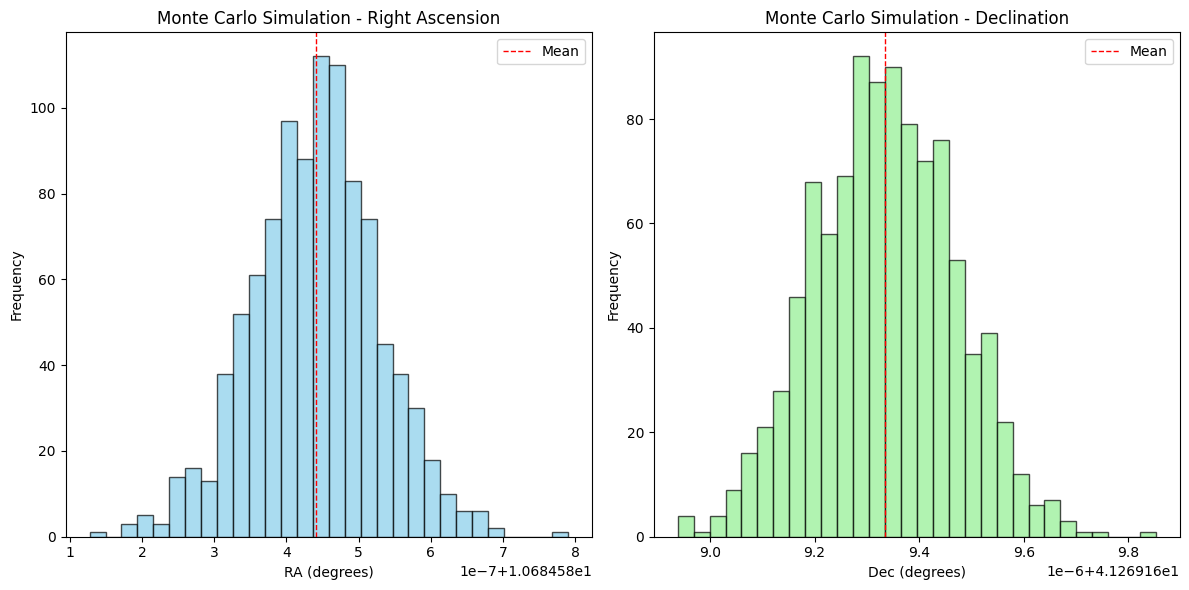

In [29]:
import astropy.coordinates as coord
import astropy.units as u
from astropy.time import Time

# Define the coordinates of the celestial object
ra = 10.68458 * u.deg
dec = 41.26917 * u.deg
distance = 10 * u.pc  # Assume a distance of 10 parsecs for this example

# Define the proper motion and radial velocity
pm_ra = 0.05 * u.mas/u.yr
pm_dec = -0.1 * u.mas/u.yr
radial_velocity = 50 * u.km/u.s

# Create a SkyCoord object
source_coord = coord.SkyCoord(ra=ra, dec=dec, pm_ra_cosdec=pm_ra, pm_dec=pm_dec, radial_velocity=radial_velocity, distance=distance, obstime='J2000')

# Apply space motion to get the current position
current_time = '2024-1-1'  # The current time in years
current_coord = source_coord.apply_space_motion(new_obstime=Time(current_time))




## Monte carlo centred around the pm

import numpy as np

# Define standard deviations for proper motion errors
pm_ra_error = 0.01  # in mas/yr
pm_dec_error = 0.02  # in mas/yr

# Number of Monte Carlo samples
num_samples = 1000

# Sample proper motion values from Gaussian distributions
pm_ra_samples = np.random.normal(pm_ra.value, pm_ra_error, num_samples) * u.mas/u.yr
pm_dec_samples = np.random.normal(pm_dec.value, pm_dec_error, num_samples) * u.mas/u.yr

# Initialize arrays to store Monte Carlo results
monte_carlo_ra = np.zeros(num_samples) * u.deg
monte_carlo_dec = np.zeros(num_samples) * u.deg

# Perform Monte Carlo simulation
for i in range(num_samples):
    # Create SkyCoord object with sampled proper motion values
    source_coord_sampled = coord.SkyCoord(ra=ra, dec=dec, pm_ra_cosdec=pm_ra_samples[i],
                                          pm_dec=pm_dec_samples[i], radial_velocity=radial_velocity,
                                          distance=distance, obstime='J2000')
    
    # Apply space motion to get the current position
    current_coord_sampled = source_coord_sampled.apply_space_motion(new_obstime=Time(current_time))
    
    # Store current position coordinates
    monte_carlo_ra[i] = current_coord_sampled.ra
    monte_carlo_dec[i] = current_coord_sampled.dec

# Calculate mean and standard deviation of Monte Carlo samples
mean_ra = np.mean(monte_carlo_ra)
std_ra = np.std(monte_carlo_ra)
mean_dec = np.mean(monte_carlo_dec)
std_dec = np.std(monte_carlo_dec)

print("Mean RA:", mean_ra)
print("Standard deviation of RA:", std_ra)
print("Mean Dec:", mean_dec)
print("Standard deviation of Dec:", std_dec)


import matplotlib.pyplot as plt

# Plot histograms for right ascension and declination
plt.figure(figsize=(12, 6))

# Plot histogram for right ascension
plt.subplot(1, 2, 1)
plt.hist(monte_carlo_ra, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(mean_ra.value, color='r', linestyle='--', linewidth=1, label='Mean')
plt.xlabel('RA (degrees)')
plt.ylabel('Frequency')
plt.title('Monte Carlo Simulation - Right Ascension')
plt.legend()

# Plot histogram for declination
plt.subplot(1, 2, 2)
plt.hist(monte_carlo_dec, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(mean_dec.value, color='r', linestyle='--', linewidth=1, label='Mean')
plt.xlabel('Dec (degrees)')
plt.ylabel('Frequency')
plt.title('Monte Carlo Simulation - Declination')
plt.legend()

plt.tight_layout()
plt.show()